In [ ]:
# install package
!pip install ucimlrepo


In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
# fetch dataset
phishing_websites = fetch_ucirepo(id=327)


#  data (as pandas dataframes)
X = phishing_websites.data.features
y = phishing_websites.data.targets.squeeze()


df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
df.head()

Shape: (11055, 31)


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [ ]:
#  data inspection
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())

df.describe()

Index(['having_ip_address', 'url_length', 'shortining_service',
       'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix',
       'having_sub_domain', 'sslfinal_state', 'domain_registration_length',
       'favicon', 'port', 'https_token', 'request_url', 'url_of_anchor',
       'links_in_tags', 'sfh', 'submitting_to_email', 'abnormal_url',
       'redirect', 'on_mouseover', 'rightclick', 'popupwindow', 'iframe',
       'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank',
       'google_index', 'links_pointing_to_page', 'statistical_report',
       'result'],
      dtype='object')
having_ip_address             int64
url_length                    int64
shortining_service            int64
having_at_symbol              int64
double_slash_redirecting      int64
prefix_suffix                 int64
having_sub_domain             int64
sslfinal_state                int64
domain_registration_length    int64
favicon                       int64
port                          int64

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


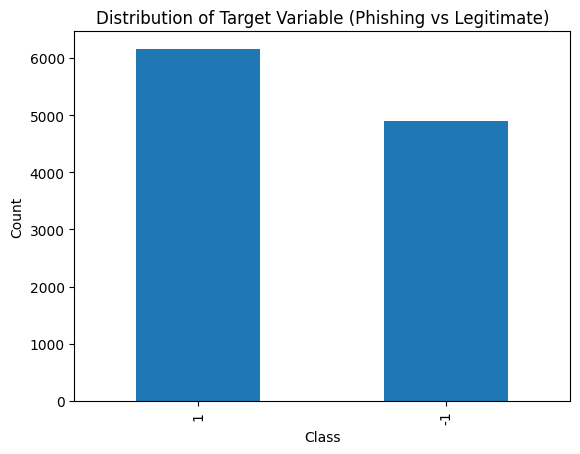

In [ ]:
# charts Distribution of phishing vs legitimate
y.value_counts().plot(kind='bar')
plt.title("Distribution of Target Variable (Phishing vs Legitimate)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

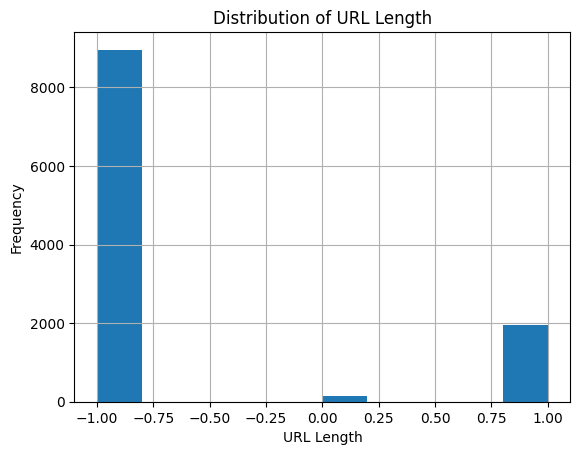

In [ ]:
# charts distribution of URL length
X['url_length'].hist()
plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.show()

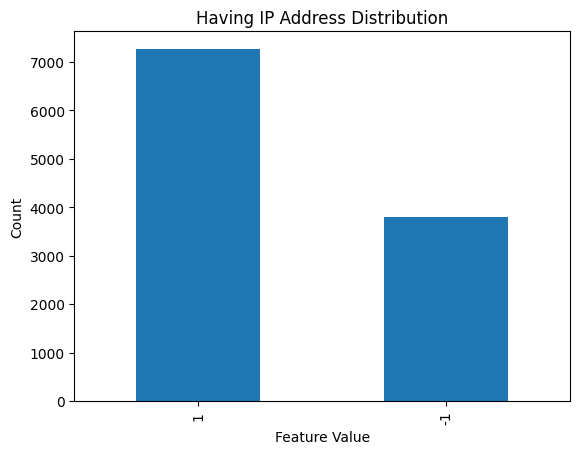

In [ ]:
# charts having IP adress distribution
X['having_ip_address'].value_counts().plot(kind='bar')
plt.title("Having IP Address Distribution")
plt.xlabel("Feature Value")
plt.ylabel("Count")
plt.show()

In [ ]:
# scale features
X_cluster = X.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_cluster.columns)

print("Scaled data shape:", X_scaled.shape)
X_scaled_df.head()

Scaled data shape: (11055, 30)


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1.383683,2.131943,0.387614,0.4196,-2.595415,-0.390849,-1.301501,-1.371855,-0.704374,0.477557,...,0.21212,0.489518,0.317438,-1.063235,-1.486897,-1.555270,-0.589921,0.402154,1.151029,-2.476340
1,0.722709,2.131943,0.387614,0.4196,0.385295,-0.390849,-0.078232,0.821486,-0.704374,0.477557,...,0.21212,0.489518,0.317438,-1.063235,-1.486897,-0.347097,-0.589921,0.402154,1.151029,0.403822
2,0.722709,0.826563,0.387614,0.4196,0.385295,-0.390849,-1.301501,-1.371855,-0.704374,0.477557,...,0.21212,0.489518,0.317438,0.940526,-1.486897,0.861076,-0.589921,0.402154,-0.603608,-2.476340
3,0.722709,0.826563,0.387614,0.4196,0.385295,-0.390849,-1.301501,-1.371855,1.419700,0.477557,...,0.21212,0.489518,0.317438,-1.063235,-1.486897,0.861076,-0.589921,0.402154,-2.358245,0.403822
4,0.722709,0.826563,-2.579887,0.4196,0.385295,-0.390849,1.145038,0.821486,-0.704374,0.477557,...,0.21212,-2.042826,0.317438,-1.063235,-1.486897,-0.347097,-0.589921,0.402154,1.151029,0.403822


In [ ]:
# checking scaled data
X_scaled_df.describe()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
count,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,...,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04,1.105500e+04
mean,1.645400e-16,1.285469e-17,-1.446152e-18,2.056750e-17,-1.012306e-17,4.981191e-18,-2.056750e-17,-1.478289e-17,4.370593e-17,-4.049226e-17,...,4.949054e-17,3.743927e-17,-1.426870e-16,8.226999e-17,-1.234050e-16,-1.073366e-16,-8.226999e-17,2.313843e-17,-1.253332e-17,2.056750e-17
std,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,...,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00
min,-1.383683e+00,-4.788163e-01,-2.579887e+00,-2.383224e+00,-2.595415e+00,-3.908495e-01,-1.301501e+00,-1.371855e+00,-7.043741e-01,-2.093992e+00,...,-4.714318e+00,-2.042826e+00,-3.150224e+00,-1.063235e+00,-1.486897e+00,-1.555270e+00,-5.899206e-01,-2.486611e+00,-2.358245e+00,-2.476340e+00
25%,-1.383683e+00,-4.788163e-01,3.876139e-01,4.195996e-01,3.852948e-01,-3.908495e-01,-1.301501e+00,-1.371855e+00,-7.043741e-01,4.775567e-01,...,2.121198e-01,4.895178e-01,3.174377e-01,-1.063235e+00,-1.486897e+00,-3.470971e-01,-5.899206e-01,4.021537e-01,-6.036079e-01,4.038218e-01
50%,7.227087e-01,-4.788163e-01,3.876139e-01,4.195996e-01,3.852948e-01,-3.908495e-01,-7.823173e-02,8.214859e-01,-7.043741e-01,4.775567e-01,...,2.121198e-01,4.895178e-01,3.174377e-01,9.405260e-01,6.725416e-01,8.610762e-01,-5.899206e-01,4.021537e-01,-6.036079e-01,4.038218e-01
75%,7.227087e-01,-4.788163e-01,3.876139e-01,4.195996e-01,3.852948e-01,-3.908495e-01,1.145038e+00,8.214859e-01,1.419700e+00,4.775567e-01,...,2.121198e-01,4.895178e-01,3.174377e-01,9.405260e-01,6.725416e-01,8.610762e-01,1.695143e+00,4.021537e-01,1.151029e+00,4.038218e-01
max,7.227087e-01,2.131943e+00,3.876139e-01,4.195996e-01,3.852948e-01,2.558530e+00,1.145038e+00,8.214859e-01,1.419700e+00,4.775567e-01,...,2.121198e-01,4.895178e-01,3.174377e-01,9.405260e-01,6.725416e-01,8.610762e-01,1.695143e+00,4.021537e-01,1.151029e+00,4.038218e-01


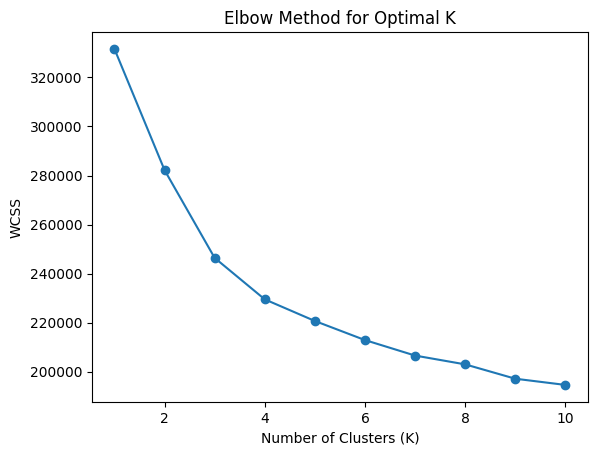

In [ ]:
# elbow method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# WCSS values
for k, value in zip(range(1, 11), wcss):
    print(f"K={k}: WCSS={value}")

K=1: WCSS=331649.9999999996
K=2: WCSS=282208.79701995716
K=3: WCSS=246378.72113370008
K=4: WCSS=229464.1865802434
K=5: WCSS=220639.00691544986
K=6: WCSS=212849.04887723541
K=7: WCSS=206524.78220749128
K=8: WCSS=202934.8076148375
K=9: WCSS=197075.80109496714
K=10: WCSS=194546.13411652044


In [ ]:
# final k-means model
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [ ]:
# silouette score
sil_score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.2844769527919786


In [ ]:
# cluster distribution
df['Cluster'].value_counts()

,count
Cluster,
2,8300
0,1577
1,1178


In [ ]:
# cluster distribution with percentages
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_percentages = df['Cluster'].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    "Count": cluster_counts,
    "Percentage": cluster_percentages
})

cluster_summary

,Count,Percentage
Cluster,,
0,1577,14.265038
1,1178,10.655812
2,8300,75.079150


In [ ]:
# cluster centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)

centroids

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-0.117444,0.069162,0.129816,-0.851180,0.063975,0.080453,0.008646,0.032189,-0.114428,-2.049964,...,-1.234260,-1.933632,-1.795703,-0.020059,-0.102501,0.111810,-0.046548,0.046782,0.243113,-0.810704
1,-1.144077,0.232604,-2.519429,-0.170469,-2.501793,0.250102,0.145031,0.258255,-0.179666,0.156659,...,0.191210,0.078926,0.232071,0.185288,-1.257755,0.204683,-0.027384,-0.431615,0.632682,-0.116954
2,0.184691,-0.046154,0.332912,0.185918,0.342918,-0.050782,-0.022227,-0.042770,0.047241,0.367259,...,0.207371,0.356188,0.308246,-0.022486,0.197985,-0.050294,0.012731,0.052370,-0.135987,0.170633


In [ ]:
# cluster VS target cross tab
pd.crosstab(df['Cluster'], y)

result,-1,1
Cluster,,
0,690,887
1,373,805
2,3835,4465


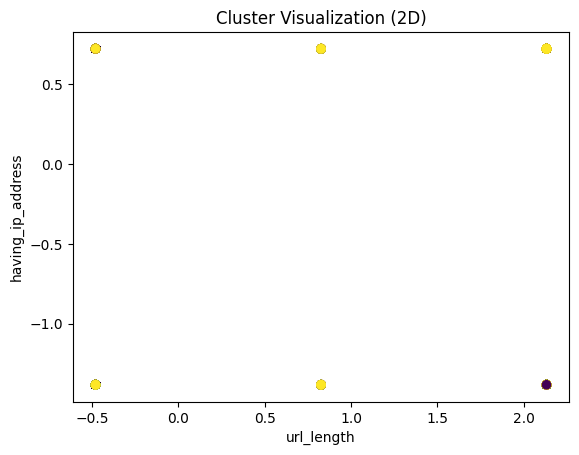

In [ ]:
# 2D chart
plt.scatter(
    X_scaled[:, X.columns.get_loc('url_length')],
    X_scaled[:, X.columns.get_loc('having_ip_address')],
    c=clusters
)

plt.xlabel("url_length")
plt.ylabel("having_ip_address")
plt.title("Cluster Visualization (2D)")
plt.show()

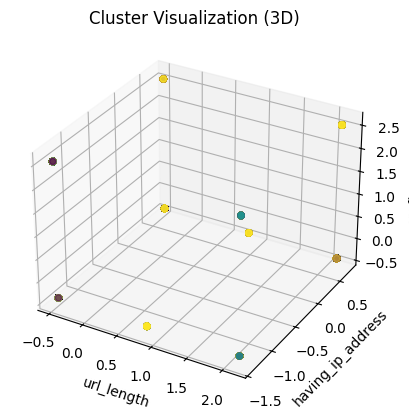

In [ ]:
# 3D chart
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_scaled[:, X.columns.get_loc('url_length')],
    X_scaled[:, X.columns.get_loc('having_ip_address')],
    X_scaled[:, X.columns.get_loc('prefix_suffix')],
    c=clusters
)

ax.set_xlabel('url_length')
ax.set_ylabel('having_ip_address')
ax.set_zlabel('prefix_suffix')
plt.title("Cluster Visualization (3D)")
plt.show()